<a href="https://colab.research.google.com/github/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/blob/main/notebooks/02.5_Anexo_de_clase_de_visualizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---
Clase 2.5 (anexo)- Manipulación de datos organizacionales y visualización


⏩ Vamos a utilizar lo que conocemos sobre matrices para armar tablas de datos organizacionales y trabajar con ellas

---
Una matriz es un arreglo rectangular de números con n filas × m columnas.

🌐 **En la práctica organizacional:**  
Cada fila representa un elemento (ej: planta, producto) y cada columna un atributo (ej: ventas, costos).


✅ Paso 1

---

Importamos librerías que vamos a utilizar

In [ ]:
#Importamos las librerías que vamos a utilizar
import numpy as np #para hacer operaciones matemáticas
import pandas as pd #para manejo de archivos de datos
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

✅ Paso 2

---

Construímos tablas de datos organizacionales

In [ ]:
# Armamos una matriz que contenga datos de producción (en unidades)

matriz_produccion = np.array([
    [150, 200, 100],  # Planta Norte
    [180, 150, 120],  # Planta Centro
    [90, 110, 130]    # Planta Sur
])
print(matriz_produccion)

[[150 200 100]
 [180 150 120]
 [ 90 110 130]]


In [ ]:
# Ahora la convertimos en una tabla de datos con las etiquetas correspondientes

data_produccion = pd.DataFrame(
    matriz_produccion,
    index=["Planta Norte", "Planta Centro", "Planta Sur"],
    columns=["Producto A", "Producto B", "Producto C"]
)

#la visualizamos
data_produccion

,Producto A,Producto B,Producto C
Planta Norte,150,200,100
Planta Centro,180,150,120
Planta Sur,90,110,130


✅ Paso 3

---
Realizamos operaciones básicas con la tabla de datos


In [ ]:
# Agregamos una columna de producción total por planta
data_produccion["Total Unidades"] = data_produccion.sum(axis=1)
data_produccion

,Producto A,Producto B,Producto C,Total Unidades
Planta Norte,150,200,100,450
Planta Centro,180,150,120,450
Planta Sur,90,110,130,330


In [ ]:
#Armamos una tabla que contenga los porcentajes de contribución de cada producto
data_porcentaje = data_produccion.div(data_produccion["Total Unidades"], axis=0) * 100
data_porcentaje

,Producto A,Producto B,Producto C,Total Unidades
Planta Norte,33.333333,44.444444,22.222222,100.0
Planta Centro,40.000000,33.333333,26.666667,100.0
Planta Sur,27.272727,33.333333,39.393939,100.0


In [ ]:
# Calculamos los totales por producto
total_producto_A = data_produccion["Producto A"].sum()
total_producto_B = data_produccion["Producto B"].sum()
total_producto_C = data_produccion["Producto C"].sum()

print("Totales por Producto:")
print("Producto A:", total_producto_A)
print("Producto B:", total_producto_B)
print("Producto C:", total_producto_C)
print("Total Unidades:", data_produccion["Total Unidades"].sum())


Totales por Producto:
Producto A: 420
Producto B: 460
Producto C: 350
Total Unidades: 1230


✅ Paso 4

---
Hacemos algunos gráficos para visualizar datos de la tabla


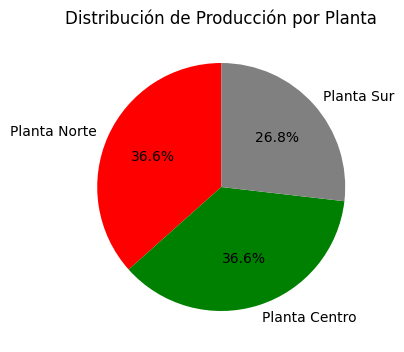

In [ ]:
#Gráfico 1 - Visualizamos como se distribuye porcentualmente la producción respecto de cada  de cada planta
#Para esto hacemos un gráfico de torta
colores1=["red","green","grey"]
plt.figure(figsize=(4, 5))
plt.pie(data_produccion["Total Unidades"], labels=data_produccion.index,colors=colores1, autopct='%1.1f%%', startangle=90)
plt.title("Distribución de Producción por Planta")
plt.show()

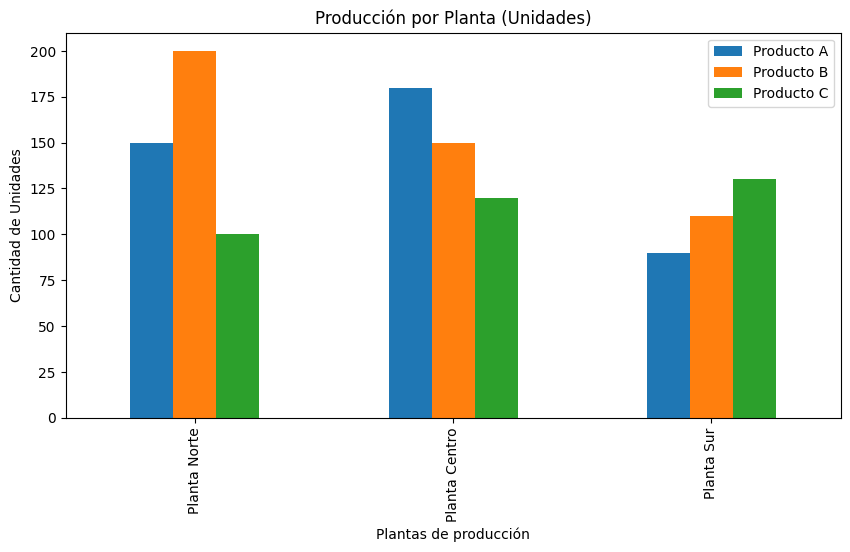

In [ ]:
#Gráfico 2:Visualizamos la cantidad en unidades de producción de cada producto en cada planta
#Para esto hacemos un gráfico de barras
plt.figure(figsize=(10, 5))
data_produccion.loc[:, ["Producto A","Producto B","Producto C"]].plot(kind='bar', ax=plt.gca())
plt.title("Producción por Planta (Unidades)")
plt.ylabel("Cantidad de Unidades")
plt.xlabel("Plantas de producción")
plt.show()

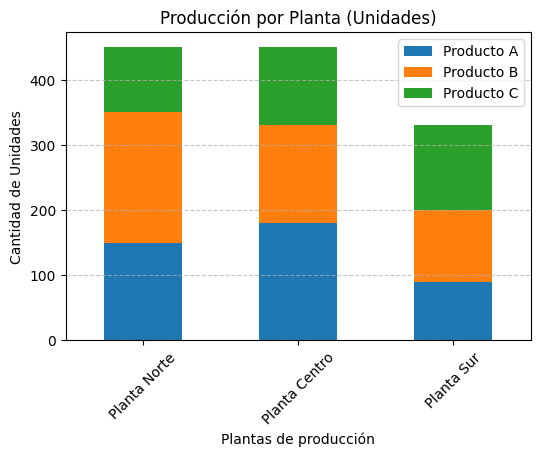

In [ ]:
# Gráfico 3: Visualizamos la producción por planta, destacando la cantidad por producto
#Para esto hacemos un gráfico de barras apiladas
plt.figure(figsize=(6, 4))
data_produccion.loc[:, ["Producto A","Producto B","Producto C"]].plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Producción por Planta (Unidades)")
plt.ylabel("Cantidad de Unidades")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Plantas de producción")
plt.show()


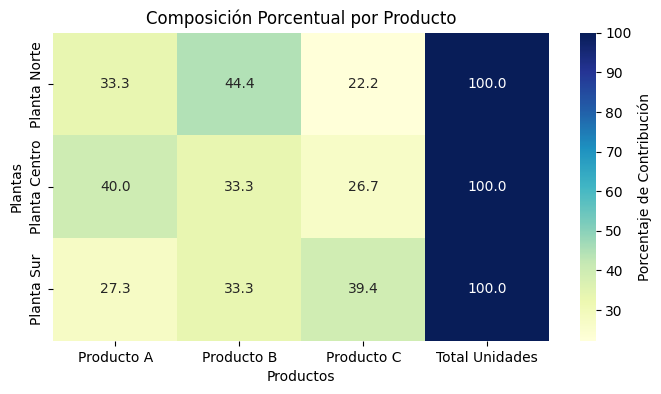

In [ ]:
# Gráfico 4: Visualizamos la composición porcentual de cada producto en cada planta
# Para esto hacemos un mapa de calor
plt.figure(figsize=(8, 4))
sns.heatmap(data_porcentaje, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={'label': 'Porcentaje de Contribución'})
plt.title("Composición Porcentual por Producto")
plt.xlabel("Productos")
plt.ylabel("Plantas")


plt.show()

⏩ Vamos a analizar las ventas de una empresa

---



✅ Paso 1

---

Armamos una matriz con las ventas trimestrales de una empresa que ofrece 3 productos.

Como en el año tenemos 4 trimestres, y vendemos 3 productos, haremos una matriz de 4 x 3 ( las filas representan las ventas por trimestres y las columnas corresponden a las cantidades vendidas de cada producto)

Luego convertimos la matriz en una tabla de datos.

In [ ]:
# Cargamos las cantidades trimestrales por producto vendidas(en unidades) en una matriz de ventas trimestrales (matriz 4x3)
matriz_ventas = np.array([
    [120, 85, 150],   # T1-Trimestre 1
    [95, 73, 130],    # T2-Trimestre 2
    [110, 90, 145],   # T3-Trimestre 3
    [105, 80, 120]    # T4-Trimestre 4
])
print(matriz_ventas)

[[120  85 150]
 [ 95  73 130]
 [110  90 145]
 [105  80 120]]


In [ ]:
# Creamos la tabla de datos a partir de la matriz
datos_ventas = pd.DataFrame(
    matriz_ventas,
    index=["T1", "T2", "T3", "T4"],
    columns=["Producto X", "Producto Y", "Producto Z"]
)
datos_ventas

,Producto X,Producto Y,Producto Z
T1,120,85,150
T2,95,73,130
T3,110,90,145
T4,105,80,120


✅ Paso 2

---

Armamos los vectores de precios unitarios por trimestre para calcular los ingresos por ventas trimestrales.

Luego añadimos la información a la tabla de datos.

In [ ]:
#Generamos los vectores columna de precios, uno para cada trimestre
vector_precios_trimestre_1 = np.array([[45], [75],[30]])
vector_precios_trimestre_2 = np.array([[50], [79], [35]])
vector_precios_trimestre_3 = np.array([[55], [82],[41]])
vector_precios_trimestre_4 = np.array([[60], [88], [54]])


In [ ]:
vector_precios_trimestre_1

array([[45],
       [75],
       [30]])

In [ ]:
#Conformamos un matriz de precios a partir de los vectores
matriz_precios_por_trimestre = np.concatenate((vector_precios_trimestre_1,
                                               vector_precios_trimestre_2,
                                               vector_precios_trimestre_3,
                                               vector_precios_trimestre_4), axis=1)
matriz_precios_por_trimestre

array([[45, 50, 55, 60],
       [75, 79, 82, 88],
       [30, 35, 41, 54]])

In [ ]:
#Ahora trasponemos la matriz y la convertimos en una tabla de datos
tabla_precios=pd.DataFrame(matriz_precios_por_trimestre.T, index=["T1", "T2", "T3", "T4"], columns=["Precios X", "Precios Y", "Precios Z"])
tabla_precios

,Precios X,Precios Y,Precios Z
T1,45,75,30
T2,50,79,35
T3,55,82,41
T4,60,88,54


In [ ]:
#Unimos ambas tablas de datos para constituir una sola con toda la información
datos_ventas=pd.concat([datos_ventas, tabla_precios], axis=1)
datos_ventas

,Producto X,Producto Y,Producto Z,Precios X,Precios Y,Precios Z
T1,120,85,150,45,75,30
T2,95,73,130,50,79,35
T3,110,90,145,55,82,41
T4,105,80,120,60,88,54


In [ ]:
#Agregamos un columna para registrar el total de ingresos por trimestre
datos_ventas["Total Ingresos"]=datos_ventas['Producto X']*datos_ventas['Precios X']+datos_ventas['Producto Y']*datos_ventas['Precios Y']+datos_ventas['Producto Z']*datos_ventas['Precios Z']
datos_ventas

,Producto X,Producto Y,Producto Z,Precios X,Precios Y,Precios Z,Total Ingresos
T1,120,85,150,45,75,30,16275
T2,95,73,130,50,79,35,15067
T3,110,90,145,55,82,41,19375
T4,105,80,120,60,88,54,19820


✅ Paso 3

---
Hacemos algunos gráficos para visualizar datos de la tabla


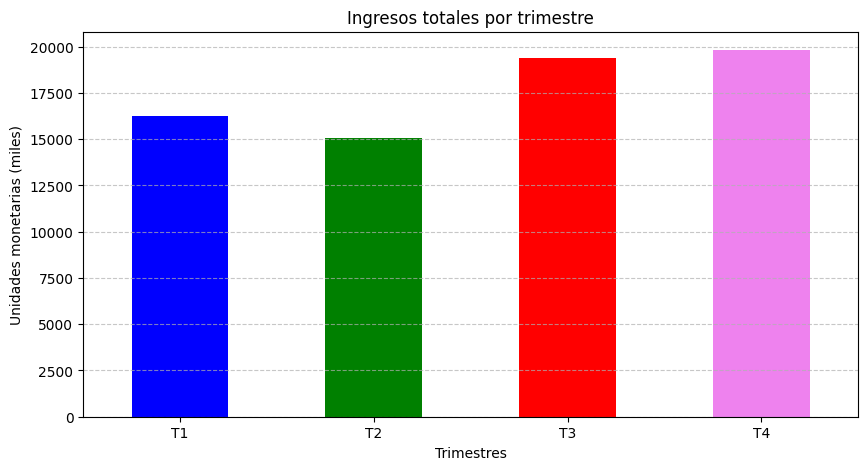

In [ ]:
# Vamos a graficar los ingresos totales por trimestre
# Para eso hacemos un gráfico de barras
datos = datos_ventas['Total Ingresos']

plt.figure(figsize=(10, 5))#establecemos el tamaño del gráfico
datos.plot(kind='bar', color=['blue', 'green', 'red','violet'])#ploteamos un gráfico de barras
plt.title('Ingresos totales por trimestre')#Le agregamos un título
plt.xlabel('Trimestres')#agregamos la etiqueta del eje x
plt.ylabel('Unidades monetarias (miles)')#agregamos la etiqueta de eje y
plt.xticks(rotation=0)  # Para que los nombres queden horizontales
plt.grid(axis='y', linestyle='--', alpha=0.7)#agregamos las líneas grises marcadoras
plt.show()#pedimos ver el gráfico

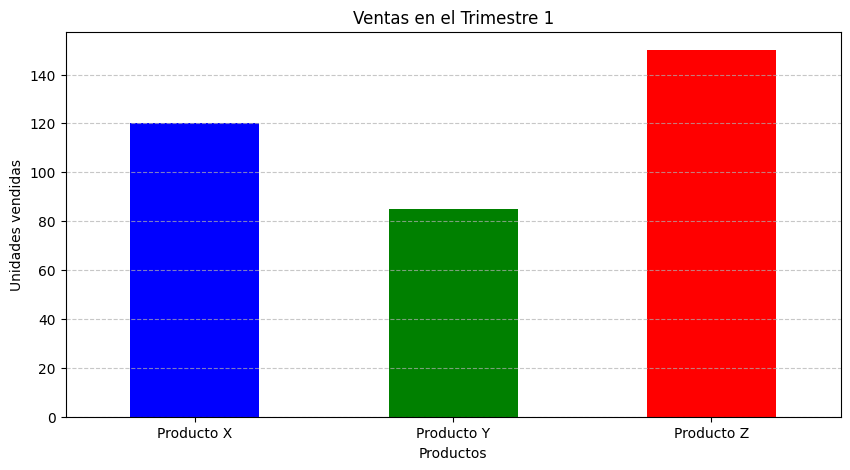

In [ ]:
#Ahora vamos a graficar las unidades vendidas de cada producto para un trimestre en particular
#Para esto hacemos un gráfico de barras

# Seleccionamos un trimestre para mostrar (en este caso T1)
datos_t1 = datos_ventas.loc['T1'][['Producto X', 'Producto Y', 'Producto Z']]

plt.figure(figsize=(10, 5))
datos_t1.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Ventas en el Trimestre 1')
plt.xlabel('Productos')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

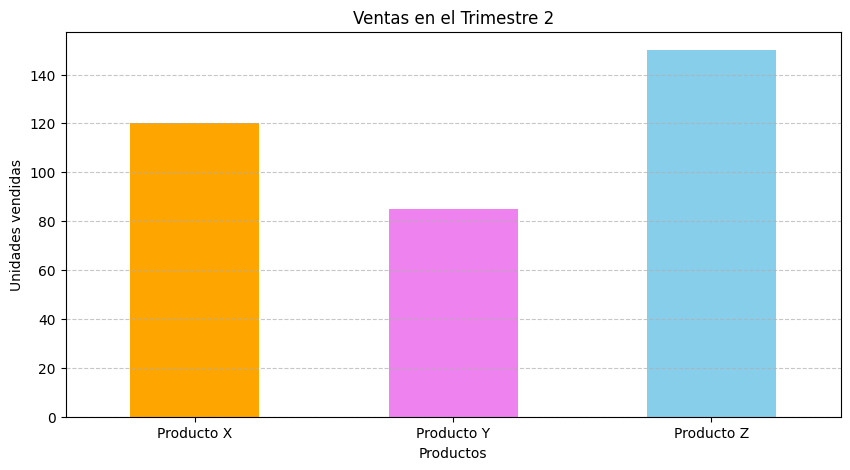

In [ ]:
# Seleccionamos un trimestre para mostrar (en este caso T2)
datos_t2 = datos_ventas.loc['T2'][['Producto X', 'Producto Y', 'Producto Z']]

plt.figure(figsize=(10, 5))
datos_t1.plot(kind='bar', color=['orange', 'violet', 'skyblue'])
plt.title('Ventas en el Trimestre 2')
plt.xlabel('Productos')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

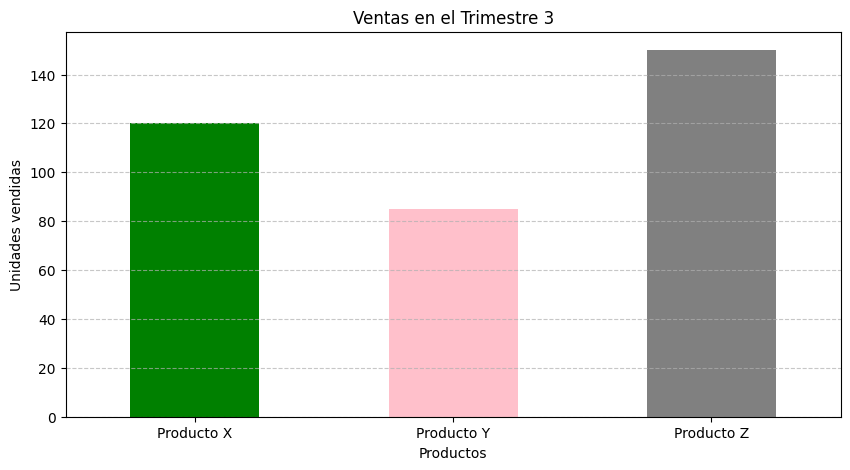

In [ ]:
# Seleccionamos un trimestre para mostrar (en este caso T3)
datos_t3 = datos_ventas.loc['T3'][['Producto X', 'Producto Y', 'Producto Z']]

plt.figure(figsize=(10, 5))
datos_t1.plot(kind='bar', color=['green', 'pink', 'grey'])
plt.title('Ventas en el Trimestre 3')
plt.xlabel('Productos')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

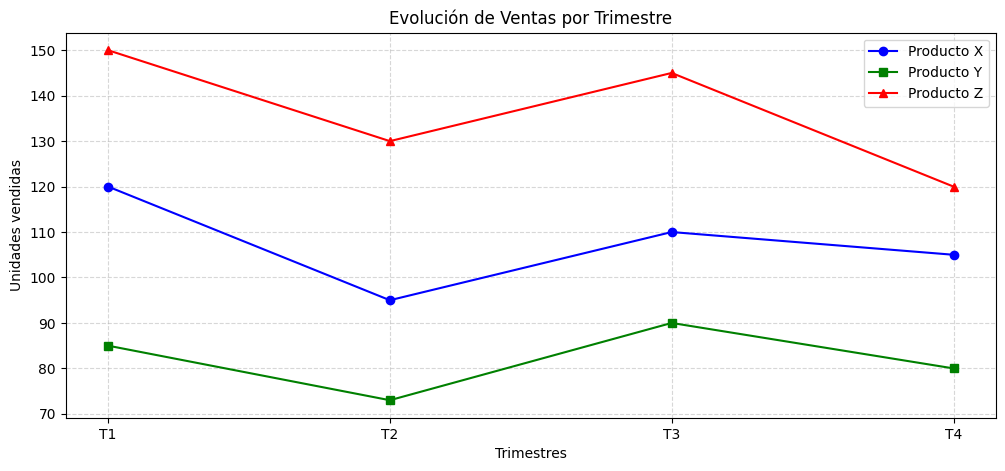

In [ ]:
#Ahora vamos a graficar la evolución de las ventas por trimestre
#Para esto hacemos un gráfico de líneas
plt.figure(figsize=(12, 5))

# Graficamos cada producto por separado
plt.plot(datos_ventas.index, datos_ventas['Producto X'], 'b-o', label='Producto X')
plt.plot(datos_ventas.index, datos_ventas['Producto Y'], 'g-s', label='Producto Y')
plt.plot(datos_ventas.index, datos_ventas['Producto Z'], 'r-^', label='Producto Z')

plt.title('Evolución de Ventas por Trimestre')
plt.xlabel('Trimestres')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

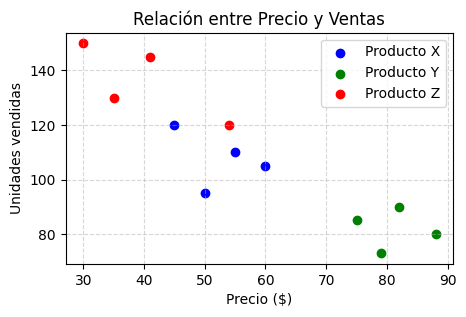

In [ ]:
#Vamos a hacer un diagrama de dispersión que muestre los precios en el eje x, cantidades vendidas en eje y
#Buscamos ver la relación entre precios y ventas para cada producto
plt.figure(figsize=(5, 3))

plt.scatter(datos_ventas['Precios X'], datos_ventas['Producto X'], color='blue', label='Producto X')
plt.scatter(datos_ventas['Precios Y'], datos_ventas['Producto Y'], color='green', label='Producto Y')
plt.scatter(datos_ventas['Precios Z'], datos_ventas['Producto Z'], color='red', label='Producto Z')

plt.title('Relación entre Precio y Ventas')
plt.xlabel('Precio ($)')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()